<a href="https://colab.research.google.com/github/Carmen10-171/04MIAR_Aprendizaje-Supervisado/blob/main/aprendizaje_supervisado_tema5_coeficiente_gini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Impureza de Gini en árboles de decisión

Este notebook explica, paso a paso, cómo un árbol de clasificación decide dónde dividir los datos. El hilo conductor adapta el ejemplo de estudiantes de Shailey Dash: queremos predecir si un estudiante **aprueba** o **suspende** un examen de *Machine Learning* a partir de su formación, su situación laboral y si sigue otros cursos en línea.

> **Nota sobre los datos.** La tabla se ha reconstruido para que sea internamente consistente: contiene 15 estudiantes, 9 aprobados y 6 suspensos. Así, cada resultado mostrado puede verificarse ejecutando el código.

Al terminar podremos:

1. interpretar la impureza de Gini de un nodo;
2. calcular el Gini ponderado de una división;
3. entender cómo el árbol elige la mejor pregunta;
4. comparar Gini con entropía;
5. relacionar el crecimiento y la poda del árbol con el sobreajuste.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score

plt.style.use("seaborn-v0_8-whitegrid")
COLORES = {"Aprueba": "#2a9d8f", "Suspende": "#e76f51"}

## 1. La idea de un árbol: hacer preguntas para separar clases

Un nodo contiene observaciones. Si mezcla estudiantes que aprueban y suspenden, el nodo es **impuro**. Una pregunta útil separa ese nodo en grupos más homogéneos.

- **Nodo raíz:** contiene todos los datos y formula la primera pregunta.
- **Nodo de decisión:** formula una pregunta posterior.
- **Hoja:** no se divide más; predice la clase mayoritaria que contiene.

El entrenamiento sigue una estrategia voraz: en cada nodo examina las divisiones disponibles y escoge la que más reduce la impureza en ese momento.

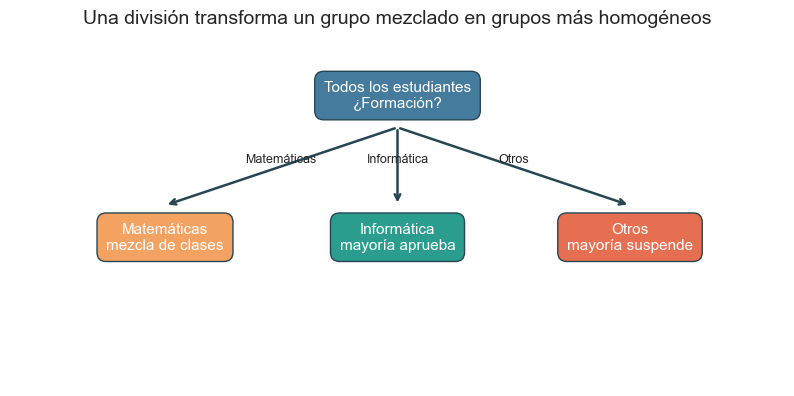

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.axis("off")

nodes = {
    "raiz": (0.50, 0.82, "Todos los estudiantes\n¿Formación?", "#457b9d"),
    "math": (0.20, 0.42, "Matemáticas\nmezcla de clases", "#f4a261"),
    "cs": (0.50, 0.42, "Informática\nmayoría aprueba", "#2a9d8f"),
    "otros": (0.80, 0.42, "Otros\nmayoría suspende", "#e76f51"),
}
for _, (x, y, label, color) in nodes.items():
    ax.text(x, y, label, ha="center", va="center", color="white", fontsize=11,
            bbox=dict(boxstyle="round,pad=.6", facecolor=color, edgecolor="#264653"))
for x, label in [(0.20, "Matemáticas"), (0.50, "Informática"), (0.80, "Otros")]:
    ax.annotate("", xy=(x, 0.51), xytext=(0.50, 0.73),
                arrowprops=dict(arrowstyle="->", lw=1.8, color="#264653"))
    ax.text((x + 0.50) / 2, 0.63, label, ha="center", fontsize=9)
ax.set_title("Una división transforma un grupo mezclado en grupos más homogéneos", fontsize=14)
plt.show()

## 2. Datos de ejemplo

Las variables predictoras son categóricas. La tabla está diseñada para que **Formación** sea una pregunta claramente útil, pero no perfecta.

In [ ]:
datos = pd.DataFrame({
    "Resultado": ["Aprueba"] * 9 + ["Suspende"] * 6,
    "Otros_cursos": ["Sí", "Sí", "No", "Sí", "No", "Sí", "No", "Sí", "No",
                       "No", "Sí", "No", "Sí", "No", "Sí"],
    "Formación": ["Matemáticas", "Informática", "Matemáticas", "Informática", "Matemáticas",
                   "Informática", "Matemáticas", "Informática", "Matemáticas",
                   "Matemáticas", "Matemáticas", "Otros", "Otros", "Otros", "Otros"],
    "Trabaja": ["No", "No", "Sí", "Sí", "No", "Sí", "Sí", "No", "Sí",
                "Sí", "No", "Sí", "No", "Sí", "No"]
})
datos.index = np.arange(1, len(datos) + 1)
datos.index.name = "Estudiante"
datos

,Resultado,Otros_cursos,Formación,Trabaja
Estudiante,,,,
1,Aprueba,Sí,Matemáticas,No
2,Aprueba,Sí,Informática,No
3,Aprueba,No,Matemáticas,Sí
4,Aprueba,Sí,Informática,Sí
5,Aprueba,No,Matemáticas,No
6,Aprueba,Sí,Informática,Sí
7,Aprueba,No,Matemáticas,Sí
8,Aprueba,Sí,Informática,No
9,Aprueba,No,Matemáticas,Sí


,Número,Proporción
Clase,,
Aprueba,9,0.6
Suspende,6,0.4


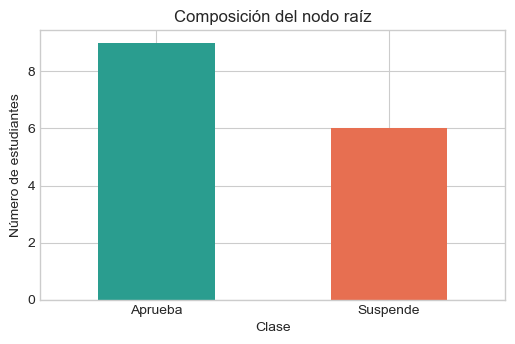

In [ ]:
resumen = datos["Resultado"].value_counts().rename_axis("Clase").to_frame("Número")
resumen["Proporción"] = resumen["Número"] / len(datos)
display(resumen)

ax = resumen["Número"].plot.bar(color=[COLORES[i] for i in resumen.index], rot=0, figsize=(6, 3.5))
ax.set_title("Composición del nodo raíz")
ax.set_ylabel("Número de estudiantes")
plt.show()

## 3. ¿Qué mide la impureza de Gini?

Para un nodo con $K$ clases, sea $p_k$ la proporción de observaciones de la clase $k$:

$$
Gini(t)=1-\sum_{k=1}^{K}p_k^2.
$$

También puede escribirse como $\sum_k p_k(1-p_k)$. Intuitivamente, mide cuánto se mezclan las clases. Equivale a la probabilidad de obtener etiquetas distintas al extraer dos etiquetas de forma independiente según las proporciones del nodo.

- $Gini=0$: el nodo es puro.
- En clasificación binaria, el máximo es $0.5$, cuando ambas clases tienen proporción $0.5$.
- Con $K$ clases equiprobables, el máximo es $1-1/K$; por eso **0.5 solo es el máximo en el caso binario**.

In [ ]:
def gini(etiquetas):
    # Impureza de Gini de una colección de etiquetas.
    proporciones = pd.Series(etiquetas).value_counts(normalize=True)
    return 1 - np.sum(proporciones ** 2)

gini_raiz = gini(datos["Resultado"])
print(f"Gini raíz = 1 - (9/15)² - (6/15)² = {gini_raiz:.3f}")

ejemplos = pd.DataFrame({
    "Composición": ["10/0", "9/1", "8/2", "7/3", "5/5"],
    "Gini": [1-(a/10)**2-(b/10)**2 for a, b in [(10,0), (9,1), (8,2), (7,3), (5,5)]]
})
ejemplos

Gini raíz = 1 - (9/15)² - (6/15)² = 0.480


,Composición,Gini
0,10/0,0.00
1,9/1,0.18
2,8/2,0.32
3,7/3,0.42
4,5/5,0.50


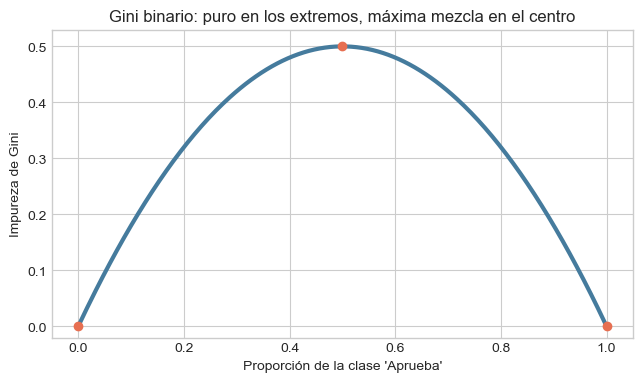

In [ ]:
p = np.linspace(0, 1, 301)
g = 1 - p**2 - (1-p)**2

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(p, g, color="#457b9d", lw=3)
ax.scatter([0, .5, 1], [0, .5, 0], color="#e76f51", zorder=3)
ax.set(xlabel="Proporción de la clase 'Aprueba'", ylabel="Impureza de Gini",
       title="Gini binario: puro en los extremos, máxima mezcla en el centro")
ax.set_ylim(-0.02, 0.53)
plt.show()

## 4. ¿Cómo se elige la primera variable?

Sí: el árbol prueba todas las variables candidatas y compara el resultado. El matiz importante es que **una variable por sí sola no tiene un coeficiente de Gini**. Lo que calculamos es el Gini de la **división que produce esa variable**.

El procedimiento para elegir la primera pregunta es siempre el mismo:

1. Partimos del nodo raíz, donde están todos los estudiantes.
2. Probamos una variable, por ejemplo `Formación`, y separamos los estudiantes según sus valores.
3. Calculamos el Gini de cada grupo resultante.
4. Combinamos esos Gini mediante una media ponderada por el tamaño de cada grupo.
5. Repetimos los pasos 2–4 para `Trabaja` y `Otros_cursos`.
6. Elegimos la variable cuyo **Gini ponderado sea menor**, porque deja los grupos más puros.

### ¿Por qué hay que ponderar?

Una pregunta genera varios nodos hijos. No basta con promediar sus impurezas: un nodo grande debe pesar más que uno pequeño. Para una división $s$:

$$
Gini_{división}(s)=\sum_{j=1}^{J}\frac{n_j}{n}\,Gini(t_j)
$$

y la mejora conseguida es:

$$
\Delta Gini = Gini(t_{padre})-Gini_{división}(s).
$$

El árbol elige la división con **menor Gini ponderado**, que equivale a la **mayor reducción de Gini**.

In [ ]:
def evaluar_division(df, variable, objetivo="Resultado"):
    filas = []
    total = len(df)
    for valor, grupo in df.groupby(variable, sort=False):
        conteos = grupo[objetivo].value_counts()
        impureza = gini(grupo[objetivo])
        filas.append({
            "Grupo": valor,
            "n": len(grupo),
            "Aprueba": conteos.get("Aprueba", 0),
            "Suspende": conteos.get("Suspende", 0),
            "Peso": len(grupo) / total,
            "Gini": impureza,
            "Contribución": len(grupo) / total * impureza,
        })
    detalle = pd.DataFrame(filas)
    gini_ponderado = detalle["Contribución"].sum()
    reduccion = gini(df[objetivo]) - gini_ponderado
    return detalle, gini_ponderado, reduccion

def dibujar_esquema_division(df, variable, objetivo="Resultado"):
    # Dibuja el nodo raíz y los hijos creados por una variable categórica.
    detalle, gini_ponderado, reduccion = evaluar_division(df, variable, objetivo)
    grupos = list(df.groupby(variable, sort=False))
    posiciones = np.linspace(0.16, 0.84, len(grupos))

    fig, ax = plt.subplots(figsize=(max(9, 3.2 * len(grupos)), 5.2))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    conteos_raiz = df[objetivo].value_counts()
    clase_raiz = conteos_raiz.idxmax()
    texto_raiz = (
        f"{variable}\n"
        f"gini = {gini(df[objetivo]):.3f}\n"
        f"samples = {len(df)}\n"
        f"value = [{conteos_raiz.get('Aprueba', 0)}, {conteos_raiz.get('Suspende', 0)}]\n"
        f"class = {clase_raiz}"
    )
    ax.text(0.5, 0.82, texto_raiz, ha="center", va="center", fontsize=10,
            bbox=dict(boxstyle="round,pad=.55", facecolor="#d9eaf7", edgecolor="#457b9d", lw=1.8))

    for x, (valor, grupo) in zip(posiciones, grupos):
        conteos = grupo[objetivo].value_counts()
        clase = conteos.idxmax()
        color = "#cce9e3" if clase == "Aprueba" else "#f7d6ce"
        texto_hijo = (
            f"gini = {gini(grupo[objetivo]):.3f}\n"
            f"samples = {len(grupo)}\n"
            f"value = [{conteos.get('Aprueba', 0)}, {conteos.get('Suspende', 0)}]\n"
            f"class = {clase}"
        )
        ax.annotate("", xy=(x, 0.43), xytext=(0.5, 0.69),
                    arrowprops=dict(arrowstyle="->", lw=1.6, color="#264653"))
        ax.text((x + 0.5) / 2, 0.57, str(valor), ha="center", va="center",
                fontsize=10, color="#264653",
                bbox=dict(facecolor="white", edgecolor="none", pad=1.5))
        ax.text(x, 0.29, texto_hijo, ha="center", va="center", fontsize=10,
                bbox=dict(boxstyle="round,pad=.5", facecolor=color, edgecolor="#264653"))

    ax.set_title(
        f"División candidata por {variable} — Gini ponderado = {gini_ponderado:.3f}",
        fontsize=14, pad=12
    )
    ax.text(0.5, 0.04, "Orden de value: [Aprueba, Suspende]", ha="center", fontsize=9)
    plt.show()

En los siguientes esquemas, `samples` es el número de estudiantes del nodo; `value` contiene los recuentos en el orden **[Aprueba, Suspende]**; y `class` es la clase mayoritaria que predeciría ese nodo. El Gini mostrado en la raíz es siempre `0.480`; lo que cambia es cómo cada variable reparte las observaciones entre sus hijos.

### 4.1. Cálculo completo para `Formación`

La variable crea tres grupos:

**Grupo Matemáticas:** 5 aprueban y 2 suspenden, en total 7.

$$
Gini(\text{Matemáticas})=1-\left(\frac{5}{7}\right)^2
-\left(\frac{2}{7}\right)^2=0.408.
$$

**Grupo Informática:** los 4 aprueban. Es un grupo puro.

$$
Gini(\text{Informática})=1-\left(\frac{4}{4}\right)^2
-\left(\frac{0}{4}\right)^2=0.
$$

**Grupo Otros:** los 4 suspenden. También es un grupo puro.

$$
Gini(\text{Otros})=1-\left(\frac{0}{4}\right)^2
-\left(\frac{4}{4}\right)^2=0.
$$

Ponderamos cada resultado por el tamaño del grupo:

$$
Gini(\text{Formación})=
\frac{7}{15}(0.408)+\frac{4}{15}(0)+\frac{4}{15}(0)
=0.190.
$$

La reducción respecto al nodo padre es:

$$
\Delta Gini(\text{Formación})=0.480-0.190=0.290.
$$

,Grupo,n,Aprueba,Suspende,Peso,Gini,Contribución
0,Matemáticas,7,5,2,0.467,0.408,0.19
1,Informática,4,4,0,0.267,0.000,0.00
2,Otros,4,0,4,0.267,0.000,0.00


Gini ponderado de Formación: 0.190
Reducción de Gini: 0.290


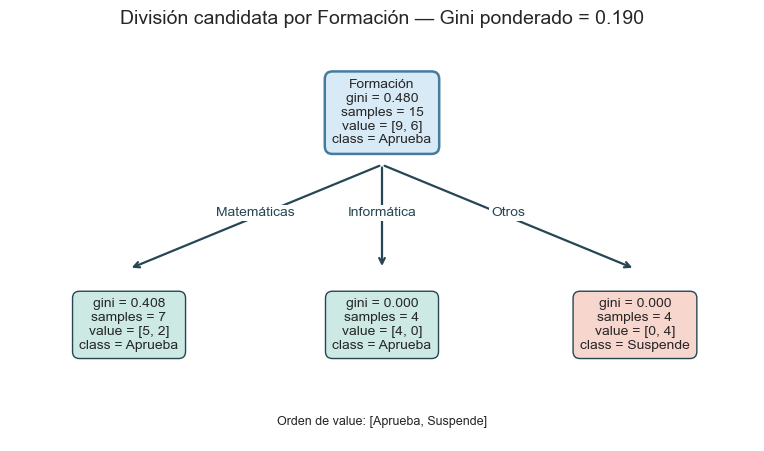

In [ ]:
detalle_formacion, gini_formacion, reduccion_formacion = evaluar_division(datos, "Formación")
display(detalle_formacion.round(3))
print(f"Gini ponderado de Formación: {gini_formacion:.3f}")
print(f"Reducción de Gini: {reduccion_formacion:.3f}")
dibujar_esquema_division(datos, "Formación")

### 4.2. Cálculo completo para `Trabaja`

La variable crea dos grupos:

**No trabaja:** 4 aprueban y 3 suspenden, en total 7.

$$
Gini(\text{No trabaja})=1-\left(\frac{4}{7}\right)^2
-\left(\frac{3}{7}\right)^2=0.490.
$$

**Sí trabaja:** 5 aprueban y 3 suspenden, en total 8.

$$
Gini(\text{Sí trabaja})=1-\left(\frac{5}{8}\right)^2
-\left(\frac{3}{8}\right)^2=0.469.
$$

El Gini ponderado de la división es:

$$
Gini(\text{Trabaja})=
\frac{7}{15}(0.490)+\frac{8}{15}(0.469)
=0.479.
$$

La reducción respecto al nodo padre es muy pequeña:

$$
\Delta Gini(\text{Trabaja})=0.480-0.479=0.001.
$$

,Grupo,n,Aprueba,Suspende,Peso,Gini,Contribución
0,No,7,4,3,0.467,0.490,0.229
1,Sí,8,5,3,0.533,0.469,0.250


Gini ponderado de Trabaja: 0.479
Reducción de Gini: 0.001


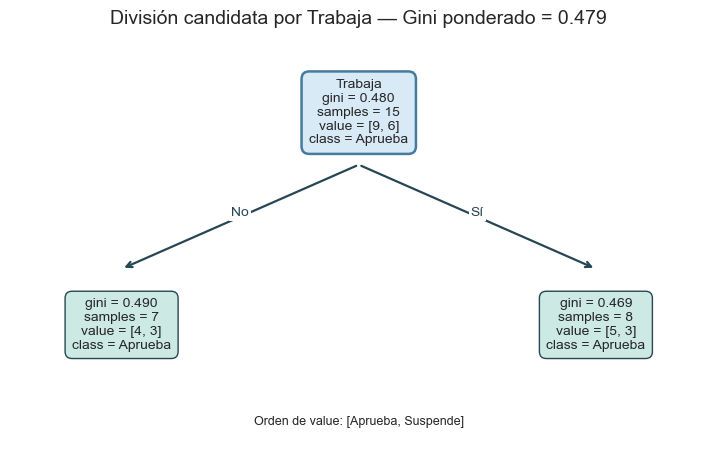

In [ ]:
detalle_trabaja, gini_trabaja, reduccion_trabaja = evaluar_division(datos, "Trabaja")
display(detalle_trabaja.round(3))
print(f"Gini ponderado de Trabaja: {gini_trabaja:.3f}")
print(f"Reducción de Gini: {reduccion_trabaja:.3f}")
dibujar_esquema_division(datos, "Trabaja")

### 4.3. Cálculo completo para `Otros_cursos`

La variable también crea dos grupos:

**No sigue otros cursos:** 4 aprueban y 3 suspenden, en total 7.

$$
Gini(\text{Otros cursos = No})=1-\left(\frac{4}{7}\right)^2
-\left(\frac{3}{7}\right)^2=0.490.
$$

**Sí sigue otros cursos:** 5 aprueban y 3 suspenden, en total 8.

$$
Gini(\text{Otros cursos = Sí})=1-\left(\frac{5}{8}\right)^2
-\left(\frac{3}{8}\right)^2=0.469.
$$

El Gini ponderado de la división es:

$$
Gini(\text{Otros cursos})=
\frac{7}{15}(0.490)+\frac{8}{15}(0.469)
=0.479.
$$

Su reducción también es prácticamente nula:

$$
\Delta Gini(\text{Otros cursos})=0.480-0.479=0.001.
$$

,Grupo,n,Aprueba,Suspende,Peso,Gini,Contribución
0,Sí,8,5,3,0.533,0.469,0.250
1,No,7,4,3,0.467,0.490,0.229


Gini ponderado de Otros_cursos: 0.479
Reducción de Gini: 0.001


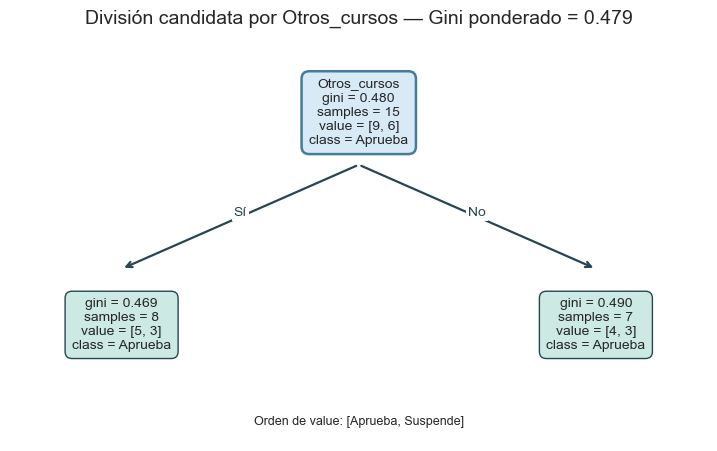

In [ ]:
detalle_cursos, gini_cursos, reduccion_cursos = evaluar_division(datos, "Otros_cursos")
display(detalle_cursos.round(3))
print(f"Gini ponderado de Otros_cursos: {gini_cursos:.3f}")
print(f"Reducción de Gini: {reduccion_cursos:.3f}")
dibujar_esquema_division(datos, "Otros_cursos")

### 4.4. Comparación final

Ya podemos reunir los tres resultados. Recuerda que buscamos el **menor Gini ponderado** o, de forma equivalente, la **mayor reducción de Gini**.

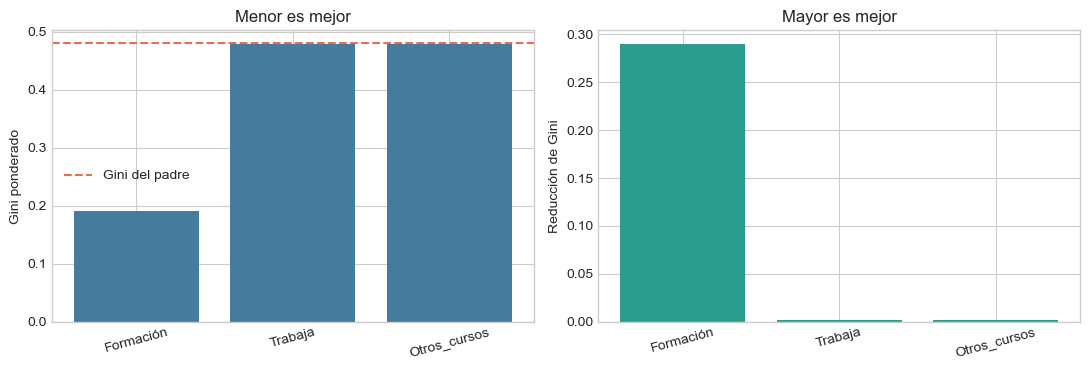

,Variable,Gini ponderado,Reducción de Gini
0,Formación,0.190,0.290
1,Trabaja,0.479,0.001
2,Otros_cursos,0.479,0.001


Conclusión: Formación es la primera variable porque produce el menor Gini ponderado (0.190) y la mayor reducción de impureza (0.290).


In [ ]:
resultados = []
for variable in ["Formación", "Trabaja", "Otros_cursos"]:
    _, impureza_hijos, reduccion = evaluar_division(datos, variable)
    resultados.append({
        "Variable": variable,
        "Gini ponderado": impureza_hijos,
        "Reducción de Gini": reduccion
    })

comparacion = pd.DataFrame(resultados).sort_values("Gini ponderado").reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(comparacion["Variable"], comparacion["Gini ponderado"], color="#457b9d")
axes[0].axhline(gini_raiz, ls="--", color="#e76f51", label="Gini del padre")
axes[0].set_title("Menor es mejor")
axes[0].set_ylabel("Gini ponderado")
axes[0].legend()
axes[1].bar(comparacion["Variable"], comparacion["Reducción de Gini"], color="#2a9d8f")
axes[1].set_title("Mayor es mejor")
axes[1].set_ylabel("Reducción de Gini")
for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

display(comparacion.round(3))
mejor = comparacion.iloc[0]
print(f"Conclusión: {mejor['Variable']} es la primera variable porque produce "
      f"el menor Gini ponderado ({mejor['Gini ponderado']:.3f}) y la mayor "
      f"reducción de impureza ({mejor['Reducción de Gini']:.3f}).")

La tabla final da una respuesta directa:

| Variable probada | Gini ponderado | Reducción de Gini | Resultado |
|---|---:|---:|---|
| Formación | 0.190 | 0.290 | Mejor división |
| Trabaja | 0.479 | 0.001 | Apenas mejora la pureza |
| Otros cursos | 0.479 | 0.001 | Apenas mejora la pureza |

Por tanto, **`Formación` se convierte en la primera variable, es decir, en la raíz del árbol**. Después se repite exactamente el mismo procedimiento dentro de cada grupo que todavía sea impuro. Por ejemplo, en el grupo de Matemáticas se volverían a comparar las variables restantes usando únicamente esos siete estudiantes.

> Regla práctica: **Gini ponderado más pequeño = mejor división**. También puede expresarse como **mayor reducción de Gini = mejor división**.

### Una precisión sobre variables categóricas

El cálculo anterior permite una rama por categoría y sirve para entender la idea. `DecisionTreeClassifier` implementa árboles CART con **divisiones binarias** y requiere convertir categorías a números. Al aplicar *one-hot encoding*, preguntas como `Formación_Informática ≤ 0.5` separan una categoría del resto. Por eso el árbol de scikit-learn puede no tener exactamente la misma forma que nuestro esquema de tres ramas.

## 5. Gini frente a entropía y ganancia de información

La entropía de un nodo es:

$$
H(t)=-\sum_{k=1}^{K}p_k\log_2(p_k),
$$

con la convención $0\log_2(0)=0$. La **ganancia de información** es la entropía del padre menos la entropía ponderada de los hijos. Ambas medidas valen cero en nodos puros y favorecen hijos homogéneos. Sus escalas difieren, y ocasionalmente pueden escoger divisiones distintas.

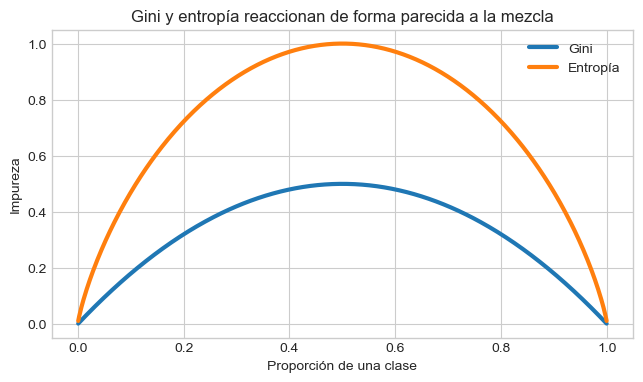

Nodo raíz — Gini: 0.480; entropía: 0.971


In [ ]:
def entropia(etiquetas):
    p = pd.Series(etiquetas).value_counts(normalize=True).to_numpy()
    return -np.sum(p * np.log2(p))

p = np.linspace(0.001, 0.999, 500)
gini_binario = 2 * p * (1-p)
entropia_binaria = -(p*np.log2(p) + (1-p)*np.log2(1-p))

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(p, gini_binario, lw=3, label="Gini")
ax.plot(p, entropia_binaria, lw=3, label="Entropía")
ax.set(xlabel="Proporción de una clase", ylabel="Impureza",
       title="Gini y entropía reaccionan de forma parecida a la mezcla")
ax.legend()
plt.show()

print(f"Nodo raíz — Gini: {gini(datos.Resultado):.3f}; entropía: {entropia(datos.Resultado):.3f}")

## 6. El mismo proceso con scikit-learn

Entrenamos un árbol pequeño usando `criterion="gini"`. En cada caja:

- `gini` es la impureza del nodo;
- `samples` es su número de observaciones;
- `value` contiene los recuentos por clase;
- `class` es la predicción mayoritaria.

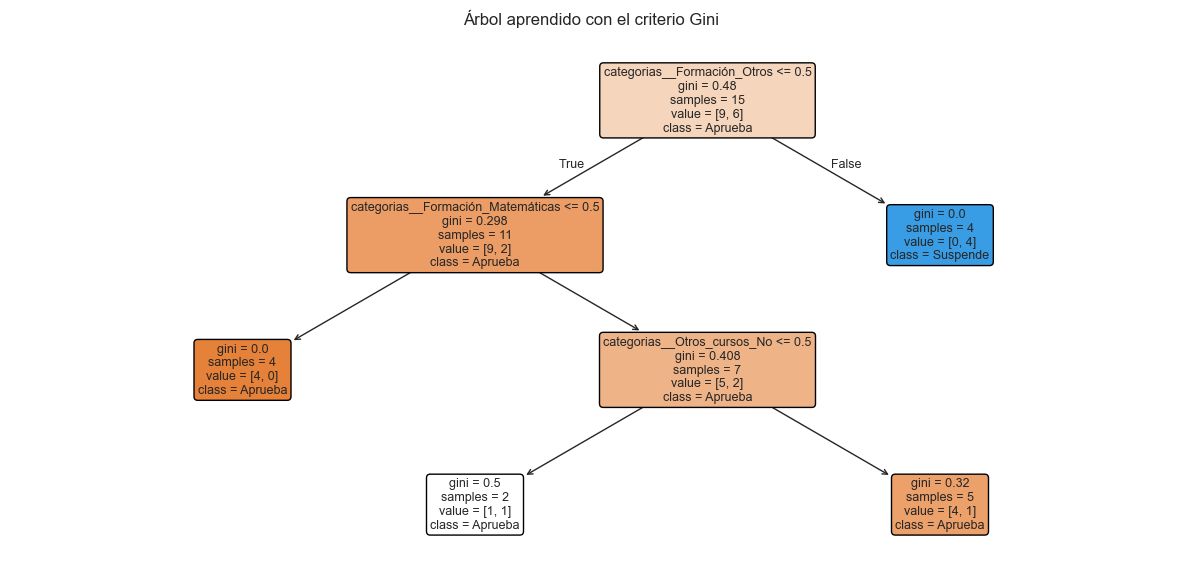

|--- categorias__Formación_Otros <= 0.50
|   |--- categorias__Formación_Matemáticas <= 0.50
|   |   |--- class: Aprueba
|   |--- categorias__Formación_Matemáticas >  0.50
|   |   |--- categorias__Otros_cursos_No <= 0.50
|   |   |   |--- class: Aprueba
|   |   |--- categorias__Otros_cursos_No >  0.50
|   |   |   |--- class: Aprueba
|--- categorias__Formación_Otros >  0.50
|   |--- class: Suspende



In [ ]:
X = datos[["Otros_cursos", "Formación", "Trabaja"]]
y = datos["Resultado"]

preprocesador = ColumnTransformer([
    ("categorias", OneHotEncoder(handle_unknown="ignore", sparse_output=False), X.columns)
])
modelo = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=42)
pipeline = make_pipeline(preprocesador, modelo)
pipeline.fit(X, y)

nombres = pipeline.named_steps["columntransformer"].get_feature_names_out()
arbol = pipeline.named_steps["decisiontreeclassifier"]

plt.figure(figsize=(15, 7))
plot_tree(arbol, feature_names=nombres, class_names=arbol.classes_,
          filled=True, rounded=True, impurity=True, proportion=False, fontsize=9)
plt.title("Árbol aprendido con el criterio Gini")
plt.show()

print(export_text(arbol, feature_names=list(nombres)))

In [ ]:
nuevo = pd.DataFrame({
    "Otros_cursos": ["Sí"],
    "Formación": ["Matemáticas"],
    "Trabaja": ["No"]
})
prediccion = pipeline.predict(nuevo)[0]
probabilidades = dict(zip(pipeline.classes_, pipeline.predict_proba(nuevo)[0].round(3)))
display(nuevo)
print("Predicción:", prediccion)
print("Probabilidades estimadas en la hoja:", probabilidades)

,Otros_cursos,Formación,Trabaja
0,Sí,Matemáticas,No


Predicción: Aprueba
Probabilidades estimadas en la hoja: {'Aprueba': np.float64(0.5), 'Suspende': np.float64(0.5)}


La predicción recorre las preguntas desde la raíz hasta una hoja. Las probabilidades son las proporciones de clases observadas en esa hoja; no deben interpretarse automáticamente como probabilidades perfectamente calibradas.

## 7. Crecimiento, sobreajuste y poda CCP

Reducir Gini una y otra vez puede producir hojas con muy pocos casos. El árbol memoriza el entrenamiento y aumenta su varianza. Se puede limitar antes de crecer mediante `max_depth`, `min_samples_split` o `min_samples_leaf`.

La poda por complejidad de coste (*Cost-Complexity Pruning*, CCP) deja crecer el árbol y penaliza después su número de hojas:

$$
R_\alpha(T)=R(T)+\alpha|T|.
$$

`ccp_alpha=0` no añade penalización. Al aumentar $\alpha$, se podan primero los eslabones más débiles y el árbol se hace menor. El valor adecuado debe seleccionarse con datos de validación o validación cruzada, no con el conjunto de prueba final.

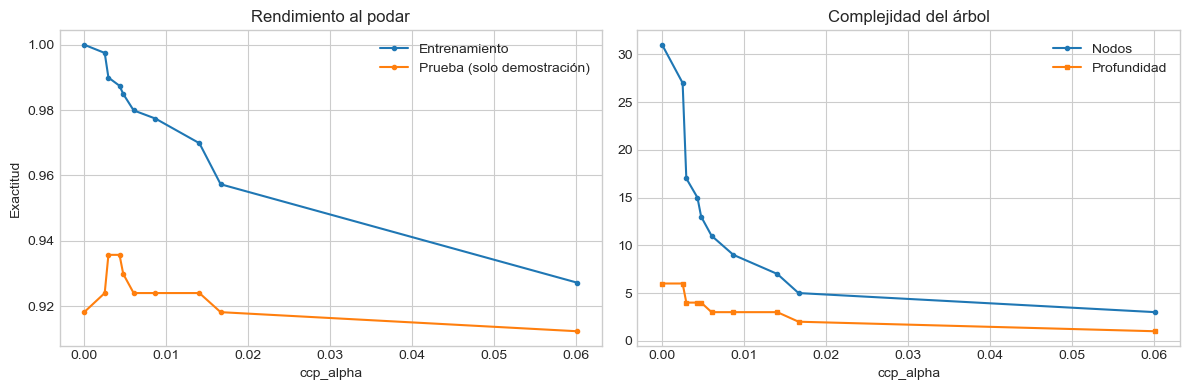

Ejemplo visual: alpha=0.00295, exactitud=0.936, nodos=17


In [ ]:
cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, test_size=0.30, stratify=cancer.target, random_state=42
)

base = DecisionTreeClassifier(random_state=42, criterion="gini")
ruta = base.cost_complexity_pruning_path(X_train, y_train)
alphas = ruta.ccp_alphas[:-1]  # se omite el árbol trivial de una sola raíz

arboles = []
for alpha in alphas:
    clf = DecisionTreeClassifier(random_state=42, criterion="gini", ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    arboles.append(clf)

train_acc = [accuracy_score(y_train, clf.predict(X_train)) for clf in arboles]
test_acc = [accuracy_score(y_test, clf.predict(X_test)) for clf in arboles]
nodos = [clf.tree_.node_count for clf in arboles]
profundidades = [clf.tree_.max_depth for clf in arboles]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(alphas, train_acc, marker="o", ms=3, label="Entrenamiento")
axes[0].plot(alphas, test_acc, marker="o", ms=3, label="Prueba (solo demostración)")
axes[0].set(xlabel="ccp_alpha", ylabel="Exactitud", title="Rendimiento al podar")
axes[0].legend()
axes[1].plot(alphas, nodos, marker="o", ms=3, label="Nodos")
axes[1].plot(alphas, profundidades, marker="s", ms=3, label="Profundidad")
axes[1].set(xlabel="ccp_alpha", title="Complejidad del árbol")
axes[1].legend()
plt.tight_layout()
plt.show()

mejor_indice = int(np.argmax(test_acc))
print(f"Ejemplo visual: alpha={alphas[mejor_indice]:.5f}, "
      f"exactitud={test_acc[mejor_indice]:.3f}, nodos={nodos[mejor_indice]}")

## 8. Ideas que conviene recordar

1. Gini mide mezcla de clases, no la calidad global del modelo.
2. Para evaluar una división se usa el promedio **ponderado** de las impurezas de sus hijos.
3. El árbol maximiza la reducción de impureza en cada nodo de forma local y voraz.
4. Gini y entropía suelen producir árboles parecidos, aunque no tienen por qué ser idénticos.
5. Una hoja no necesita ser pura: predice la clase mayoritaria.
6. Un árbol muy profundo puede sobreajustar; la profundidad, el tamaño mínimo de hoja y `ccp_alpha` controlan su complejidad.

### Comprobación rápida

Un nodo contiene 12 observaciones de la clase A y 8 de la clase B.

1. Calcula su Gini.
2. Una división produce un hijo izquierdo con $(10A,2B)$ y uno derecho con $(2A,6B)$. Calcula el Gini ponderado.
3. ¿Cuánto se reduce la impureza? ¿Aceptarías la división?

In [ ]:
# Solución de la comprobación rápida
g_padre = 1 - (12/20)**2 - (8/20)**2
g_izq = 1 - (10/12)**2 - (2/12)**2
g_der = 1 - (2/8)**2 - (6/8)**2
g_split = (12/20)*g_izq + (8/20)*g_der

print(f"Gini padre: {g_padre:.3f}")
print(f"Gini ponderado de los hijos: {g_split:.3f}")
print(f"Reducción: {g_padre - g_split:.3f}")

Gini padre: 0.480
Gini ponderado de los hijos: 0.317
Reducción: 0.163


## Referencias

- Shailey Dash, *Decision Trees Explained — Entropy, Information Gain, Gini Index, CCP Pruning*, Towards Data Science, 2022. Ejemplo de estudiantes y estructura temática adaptados con fines docentes.
- [Documentación de árboles de decisión de scikit-learn](https://scikit-learn.org/stable/modules/tree.html).
- [Ejemplo oficial de poda por complejidad de coste](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html).